#INTRODUCTION

##Business Context

Perusahaan supermarket ingin memahami perilaku customer untuk meningkatkan efektivitas campaign marketing serta mengoptimalkan strategi penjualan. Dalam industri retail, pemahaman terhadap pola pembelian customer menjadi faktor penting dalam meningkatkan revenue dan menjaga loyalitas pelanggan.

Dengan semakin banyaknya data customer yang tersedia, perusahaan dapat memanfaatkan data tersebut untuk mengidentifikasi pola pembelian, preferensi customer, serta respons terhadap berbagai strategi marketing yang telah dilakukan.

Namun, tanpa analisis yang tepat, data tersebut belum dapat memberikan nilai tambah bagi bisnis. Oleh karena itu, diperlukan proses analisis data untuk mengubah data menjadi insight yang dapat digunakan dalam pengambilan keputusan.

Selain itu, dalam analisis ini juga digunakan konsep segmentasi customer, yaitu proses mengelompokkan customer berdasarkan karakteristik tertentu seperti tingkat pengeluaran, income, atau demografi. Segmentasi ini penting karena setiap kelompok customer memiliki perilaku dan kebutuhan yang berbeda, sehingga strategi marketing yang digunakan juga harus disesuaikan.

##Business Stakeholders

Hasil analisis ini ditujukan untuk beberapa pihak dalam bisnis, yaitu:

* Marketing Team
Untuk menentukan strategi campaign yang lebih efektif dan tepat sasaran
* Sales Team
Untuk memahami customer potensial dan meningkatkan penjualan
* Business Manager / Owner
Untuk mendukung pengambilan keputusan strategis berbasis data


##Problem Statement

Terdapat beberapa permasalahan utama yang ingin dianalisis:

1. Bagaimana perusahaan bisa meningkatkan revenue?
2. Kenapa campaign tidak efektif?
3. Segmen mana yang harus diprioritaskan?

# DATA UNDERSTANDING

Sebelum melakukan analisis lebih lanjut, penting untuk memahami struktur dataset. Dataset dapat diakses [di sini](https://drive.google.com/drive/folders/1SkxkOsowm5bNkLH9G_K3jXez-kxjHtk2?usp=sharing).

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('Supermarket Customers.csv', sep='\t')
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [ ]:
# info data
print(f'Jumlah baris dan kolom di dataset df adalah {df.shape}')
df.info()


Jumlah baris dan kolom di dataset df adalah (2240, 29)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-nul

In [ ]:
# deskripsi statistik
df.describe()


,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2240.000000,2240.000000,2216.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,...,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.0,2240.0,2240.000000
mean,5592.159821,1968.805804,52247.251354,0.444196,0.506250,49.109375,303.935714,26.302232,166.950000,37.525446,...,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.009375,3.0,11.0,0.149107
std,3246.662198,11.984069,25173.076661,0.538398,0.544538,28.962453,336.597393,39.773434,225.715373,54.628979,...,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.096391,0.0,0.0,0.356274
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
25%,2828.250000,1959.000000,35303.000000,0.000000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,...,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,...,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
75%,8427.750000,1977.000000,68522.000000,1.000000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,...,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,...,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000


In [ ]:
# cek kolom
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response'],
      dtype='object')

Dataset yang digunakan berisi informasi terkait karakteristik customer, perilaku pembelian, serta respons terhadap campaign marketing yang dilakukan oleh perusahaan supermarket.

Setiap baris dalam dataset merepresentasikan satu customer, sedangkan setiap kolom merepresentasikan atribut atau informasi tertentu terkait customer tersebut.

Dataset terdiri dari data customer supermarket yang mencakup:
- Informasi demografis (umur, income, status)
- Perilaku pembelian (jumlah pembelian & spending)
- Respons terhadap campaign marketing
- Kolom Income memiliki data kosong

Jumlah data: 2240 rows
Jumlah kolom: 29 columns



##Deskripsi Variabel
Berikut adalah penjelasan untuk setiap kolom dalam dataset:

* Informasi Customer
1. ID Unique identifier untuk setiap customer
2. Year_Birth Tahun kelahiran customer
3. Education Tingkat pendidikan customer (SMA, Sarjana, dll)
4. Marital_Status
Status pernikahan customer
5. Income
Pendapatan tahunan customer
6. Kidhome
Jumlah anak kecil dalam rumah tangga customer
7. Teenhome
Jumlah remaja dalam rumah tangga customer

* Informasi Registrasi
1. Dt_Customer Tanggal pertama kali customer terdaftar
2. Recency Jumlah hari sejak terakhir kali customer melakukan pembelian

* Perilaku Pembelian (Spending)
1. MntWines Total pengeluaran untuk produk wine
2. MntFruits Total pengeluaran untuk buah
3. MntMeatProducts Total pengeluaran untuk produk daging
4. MntFishProducts Total pengeluaran untuk produk ikan
5. MntSweetProducts Total pengeluaran untuk produk manis
6. MntGoldProds Total pengeluaran untuk produk emas/premium

* Aktivitas Pembelian
1. NumDealsPurchases Jumlah pembelian dengan diskon
2. NumWebPurchases Jumlah pembelian melalui website
3. NumCatalogPurchases Jumlah pembelian melalui katalog
4. NumStorePurchases Jumlah pembelian langsung di toko
5. NumWebVisitsMonth Jumlah kunjungan ke website dalam satu bulan

* Campaign Marketing
1. AcceptedCmp1 – AcceptedCmp5
Status apakah customer menerima campaign marketing ke-1 sampai ke-5
(1 = menerima, 0 = tidak)
2. Response
Apakah customer menerima campaign terakhir

* Informasi Tambahan
1. Complain Status apakah customer pernah melakukan komplain
(1 = ya, 0 = tidak)
2. Z_CostContact Biaya untuk menghubungi customer (konstan)
3. Z_Revenue Revenue dari customer (konstan)

#DATA CLEANING

Pada tahap ini dilakukan proses pembersihan data untuk memastikan kualitas data tetap terjaga sebelum dilakukan analisis lebih lanjut.


In [ ]:
# cek duplicate
df.duplicated().sum()

np.int64(0)

In [ ]:
df['Dt_Customer'].head()

,Dt_Customer
0,04-09-2012
1,08-03-2014
2,21-08-2013
3,10-02-2014
4,19-01-2014


In [ ]:
# ubah format tanggal
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'], dayfirst=True)
df['Dt_Customer'].head()

,Dt_Customer
0,2012-09-04
1,2014-03-08
2,2013-08-21
3,2014-02-10
4,2014-01-19


## Missing values

In [ ]:
# cek missing values
df.isna().sum()

,0
ID,0
Year_Birth,0
Education,0
Marital_Status,0
Income,24
Kidhome,0
Teenhome,0
Dt_Customer,0
Recency,0
MntWines,0


In [ ]:
#Hitung persentase missing
missing_df = df['Income'].isna().mean() * 100
missing_df

np.float64(1.0714285714285714)

<Axes: xlabel='Income'>

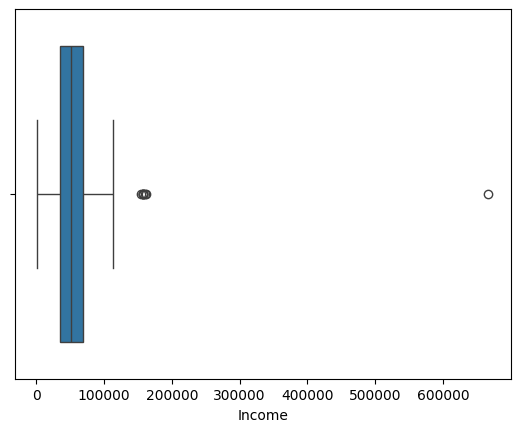

In [ ]:
#Menentukan Metode Imputasi yang Tepat mean/median, kita akan cek distribusi data Income.
import seaborn as sns
sns.boxplot(x=df['Income'])

In [ ]:
#Melakukan Imputasi dengan Median
median_income = df['Income'].median()
df['Income'].fillna(median_income, inplace=True)

/tmp/ipykernel_22877/1065906737.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Income'].fillna(median_income, inplace=True)


In [ ]:
#Cek Missing Value lagi
df['Income'].isna().sum()

np.int64(0)

In [ ]:
df.isna().sum()

,0
ID,0
Year_Birth,0
Education,0
Marital_Status,0
Income,0
Kidhome,0
Teenhome,0
Dt_Customer,0
Recency,0
MntWines,0


In [ ]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,5,0,0,0,0,0,0,3,11,0


Berdasarkan pengecekan missing value, ditemukan 24 data kosong pada variabel Income dengan persentase sebesar 1.07%. Karena persentase ini sangat kecil (<5%), data tidak dihapus melainkan dilakukan imputasi. Sebelum menentukan metode imputasi, dilakukan visualisasi distribusi data yang menunjukkan bahwa Income bersifat right-skewed dan memiliki outlier. Oleh karena itu, metode imputasi yang dipilih adalah median agar tidak terpengaruh nilai ekstrem.

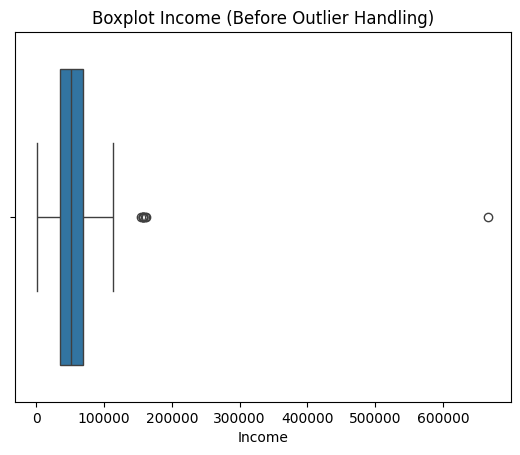

In [ ]:
# cek outlier (Income)
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x=df['Income'])
plt.title('Boxplot Income (Before Outlier Handling)')
plt.show()

Dari boxplot kolom Income diatas jelas ada outlier ekstrem di sisi kanan (right-skewed). Terlihat di boxplot
1. Mayoritas data ngumpul di kisaran kira-kira 20.000 – 100.000
Median ada di sekitar tengah box (relatif normal untuk mayoritas data)
2. Ada beberapa titik di sekitar 150.000–200.000  ini outlier ringan
3. Ada satu titik sangat jauh di sekitar 650.000  ini outlier ekstrem

Artinya distribusi Income:
Tidak normal
Condong ke kanan (positive skew)
Ada nilai yang tidak representatif terhadap mayoritas pelanggan

Berdasarkan boxplot, variabel Income menunjukkan adanya outlier ekstrem di sisi kanan yang menyebabkan distribusi tidak normal (right-skewed). Oleh karena itu dilakukan penanganan outlier sebelum proses analisis lanjutan.

In [ ]:
#Cek datanya
df[df['Income'] > 300000]

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
2233,9432,1977,Graduation,Together,666666.0,1,0,2013-06-02,23,9,...,6,0,0,0,0,0,0,3,11,0


In [ ]:
#Hitung batas outlier dengan metode IQR
Q1 = df['Income'].quantile(0.25)
Q3 = df['Income'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

lower_bound, upper_bound

(np.float64(-13587.75), np.float64(117416.25))

In [ ]:
#dentifikasi data yang termasuk outlier
outliers = df[(df['Income'] < lower_bound) | (df['Income'] > upper_bound)]
outliers

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
164,8475,1973,PhD,Married,157243.0,0,1,2014-03-01,98,20,...,0,0,0,0,0,0,0,3,11,0
617,1503,1976,PhD,Together,162397.0,1,1,2013-06-03,31,85,...,1,0,0,0,0,0,0,3,11,0
655,5555,1975,Graduation,Divorced,153924.0,0,0,2014-02-07,81,1,...,0,0,0,0,0,0,0,3,11,0
687,1501,1982,PhD,Married,160803.0,0,0,2012-08-04,21,55,...,0,0,0,0,0,0,0,3,11,0
1300,5336,1971,Master,Together,157733.0,1,0,2013-06-04,37,39,...,1,0,0,0,0,0,0,3,11,0
1653,4931,1977,Graduation,Together,157146.0,0,0,2013-04-29,13,1,...,1,0,0,0,0,0,0,3,11,0
2132,11181,1949,PhD,Married,156924.0,0,0,2013-08-29,85,2,...,0,0,0,0,0,0,0,3,11,0
2233,9432,1977,Graduation,Together,666666.0,1,0,2013-06-02,23,9,...,6,0,0,0,0,0,0,3,11,0


In [ ]:
outliers.sort_values('Income', ascending=False)

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
2233,9432,1977,Graduation,Together,666666.0,1,0,2013-06-02,23,9,...,6,0,0,0,0,0,0,3,11,0
617,1503,1976,PhD,Together,162397.0,1,1,2013-06-03,31,85,...,1,0,0,0,0,0,0,3,11,0
687,1501,1982,PhD,Married,160803.0,0,0,2012-08-04,21,55,...,0,0,0,0,0,0,0,3,11,0
1300,5336,1971,Master,Together,157733.0,1,0,2013-06-04,37,39,...,1,0,0,0,0,0,0,3,11,0
164,8475,1973,PhD,Married,157243.0,0,1,2014-03-01,98,20,...,0,0,0,0,0,0,0,3,11,0
1653,4931,1977,Graduation,Together,157146.0,0,0,2013-04-29,13,1,...,1,0,0,0,0,0,0,3,11,0
2132,11181,1949,PhD,Married,156924.0,0,0,2013-08-29,85,2,...,0,0,0,0,0,0,0,3,11,0
655,5555,1975,Graduation,Divorced,153924.0,0,0,2014-02-07,81,1,...,0,0,0,0,0,0,0,3,11,0


Keputusan penanganan Karena:
Income tinggi bisa saja valid (pelanggan kaya)
Bukan kesalahan input, maka Tidak dihapus, tapi dilakukan capping (Mengganti nilai yang terlalu ekstrem menjadi nilai batas maksimum/minimum yang masih wajar, tanpa menghapus datanya karena berdasarkan dataset costumer rata" berstatus dan memiliki tanggungan).

In [ ]:
#Lakukan capping
df['Income'] = df['Income'].clip(lower=lower_bound, upper=upper_bound)

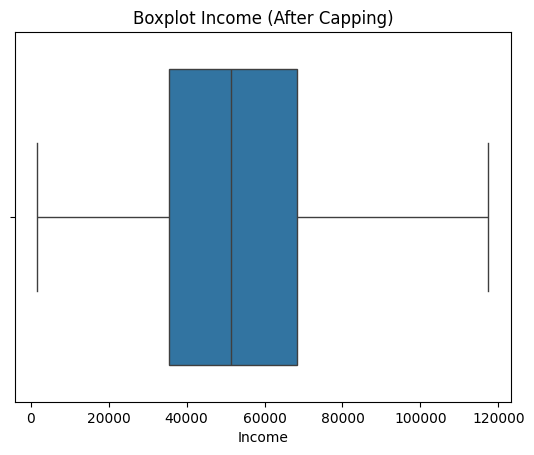

In [ ]:
#Visualisasi ulang setelah capping
sns.boxplot(x=df['Income'])
plt.title('Boxplot Income (After Capping)')
plt.show()

## data yang sudah kita bersihkan

In [ ]:
#Memastikan tidak ada lagi missing value setelah imputasi.
df.isna().sum()

,0
ID,0
Year_Birth,0
Education,0
Marital_Status,0
Income,0
Kidhome,0
Teenhome,0
Dt_Customer,0
Recency,0
MntWines,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   ID                   2240 non-null   int64         
 1   Year_Birth           2240 non-null   int64         
 2   Education            2240 non-null   object        
 3   Marital_Status       2240 non-null   object        
 4   Income               2240 non-null   float64       
 5   Kidhome              2240 non-null   int64         
 6   Teenhome             2240 non-null   int64         
 7   Dt_Customer          2240 non-null   datetime64[ns]
 8   Recency              2240 non-null   int64         
 9   MntWines             2240 non-null   int64         
 10  MntFruits            2240 non-null   int64         
 11  MntMeatProducts      2240 non-null   int64         
 12  MntFishProducts      2240 non-null   int64         
 13  MntSweetProducts     2240 non-nul

In [ ]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,5,0,0,0,0,0,0,3,11,0


In [ ]:
df.tail()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
2235,10870,1967,Graduation,Married,61223.0,0,1,2013-06-13,46,709,...,5,0,0,0,0,0,0,3,11,0
2236,4001,1946,PhD,Together,64014.0,2,1,2014-06-10,56,406,...,7,0,0,0,1,0,0,3,11,0
2237,7270,1981,Graduation,Divorced,56981.0,0,0,2014-01-25,91,908,...,6,0,1,0,0,0,0,3,11,0
2238,8235,1956,Master,Together,69245.0,0,1,2014-01-24,8,428,...,3,0,0,0,0,0,0,3,11,0
2239,9405,1954,PhD,Married,52869.0,1,1,2012-10-15,40,84,...,7,0,0,0,0,0,0,3,11,1


## REPORT DATA CLEANING

Tahap Data Cleaning ini dilakukan pembersihan data sebelum proses analisis lebih lanjut.
1. Pengecekan Missing Value
Ditemukan missing value pada kolom Income sebanyak 24 data atau sebesar 1.07% dari total data. Karena persentasenya sangat kecil (<5%), data tidak dihapus melainkan dilakukan imputasi.

2. Penentuan Metode Imputasi
Berdasarkan visualisasi distribusi menggunakan boxplot, diketahui bahwa variabel Income memiliki distribusi right-skewed dan mengandung outlier. Oleh karena itu, metode imputasi yang digunakan adalah median agar tidak terpengaruh nilai ekstrem.

3. Pengecekan Outlier
Setelah missing value ditangani, dilakukan identifikasi outlier menggunakan metode Interquartile Range (IQR). Ditemukan beberapa nilai Income yang berada di luar batas wajar.

4. Penanganan Outlier
Karena nilai Income yang tinggi masih mungkin valid secara bisnis, maka tidak dilakukan penghapusan data. Penanganan dilakukan menggunakan teknik capping (winsorizing), yaitu membatasi nilai ekstrem ke batas IQR.

5. Validasi Akhir Data
Dilakukan pengecekan ulang terhadap missing value dan tipe data.

#DATA ANALYSIS


##Tambah kolom untuk membantu analisis.

In [ ]:
#Tambahkan kolom Total_Spending
df['Total_Spending'] = df[['MntWines','MntFruits','MntMeatProducts',
                          'MntFishProducts','MntSweetProducts','MntGoldProds']].sum(axis=1)

df['Total_Spending']

,Total_Spending
0,1617
1,27
2,776
3,53
4,422
...,...
2235,1341
2236,444
2237,1241
2238,843


In [ ]:
#Tambahkan Kolom Age
df['Age'] = 2026 - df['Year_Birth']
df

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Total_Spending,Age,Segment
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,0,0,0,0,3,11,1,1617,69,High
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,0,0,0,0,3,11,0,27,72,Low
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,0,0,0,0,3,11,0,776,61,Medium
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,0,0,0,0,3,11,0,53,42,Low
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,0,0,0,0,3,11,0,422,45,Medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,10870,1967,Graduation,Married,61223.0,0,1,2013-06-13,46,709,...,0,0,0,0,3,11,0,1341,59,High
2236,4001,1946,PhD,Together,64014.0,2,1,2014-06-10,56,406,...,0,1,0,0,3,11,0,444,80,Medium
2237,7270,1981,Graduation,Divorced,56981.0,0,0,2014-01-25,91,908,...,0,0,0,0,3,11,0,1241,45,High
2238,8235,1956,Master,Together,69245.0,0,1,2014-01-24,8,428,...,0,0,0,0,3,11,0,843,70,High


##EDA (EXPLORATORY DATA ANALYSIS)

Pada tahap ini dilakukan eksplorasi data untuk memahami pola dan perilaku pelanggan.




###1. Distribusi Income

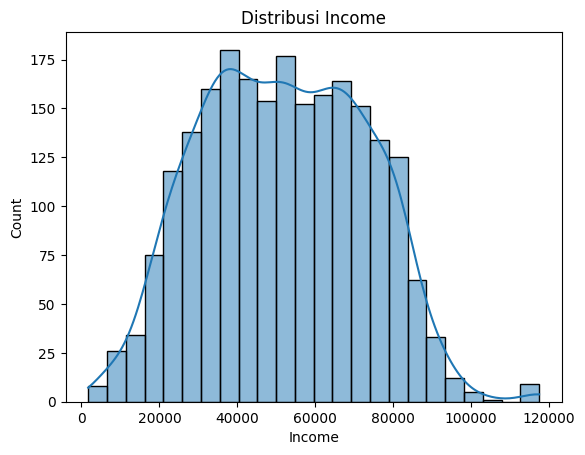

In [ ]:
sns.histplot(df['Income'], kde=True)
plt.title('Distribusi Income')
plt.show()

Berdasarkan Histogram diatas, distribusi income menunjukkan adanya variasi pelanggan, termasuk segmen dengan income tinggi yang berpotensi menjadi kontributor utama revenue.

Berdasarkan grafik tersebut dapat dilihat bahwa:
1. Sebaran income membentuk pola mendekati normal
2. Mayoritas data income berada pada rentang 20.000–80.000.
3. Nilai income yang paling sering muncul berada di sekitar 45.000–65.000.


###2. Produk Penyumbang Revenue

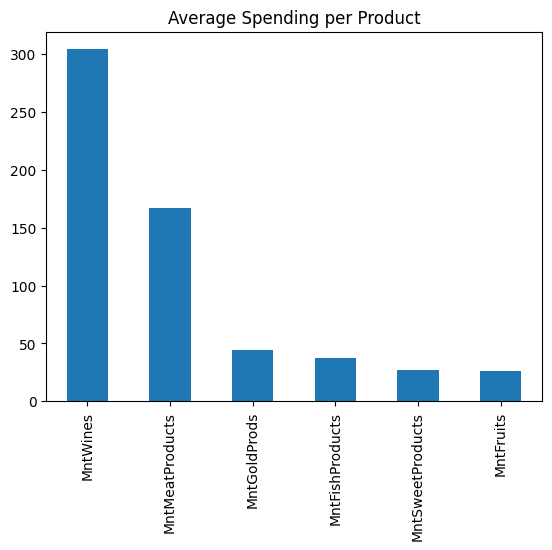

In [ ]:
df[['MntWines','MntFruits','MntMeatProducts','MntFishProducts','MntSweetProducts','MntGoldProds']
].mean().sort_values(ascending=False).plot(kind='bar')
plt.title('Average Spending per Product')
plt.show()

Berdasarkan bar chart diatas
Produk Wines dan Meat memiliki kontribusi terbesar terhadap spending,Revenue sangat bergantung pada kategori Wines → risiko tinggi jika demand turun

###3. Channel Pembelian

In [ ]:
df[['NumWebPurchases','NumStorePurchases','NumCatalogPurchases']].mean()

,0
NumWebPurchases,4.084821
NumStorePurchases,5.790179
NumCatalogPurchases,2.662054


Kesimpulan dari rata-rata channel pembelian:
* Rata-rata tertinggi ada di pembelian di toko (NumStorePurchases yaitu 5.79).
* Disusul pembelian via web (NumWebPurchases yaitu 4.08).
* Paling rendah pembelian via katalog (NumCatalogPurchases yaitu 2.66).

Artinya:
Pelanggan lebih dominan belanja langsung di toko, channel web cukup potensial sebagai pendukung, dan Channel katalog kurang diminati oleh pelanggan.

##ANALISIS UTAMA + STATISTICAL VALIDATION

Pada tahap ini dilakukan analisis mendalam terhadap hubungan antar variabel yang relevan dengan permasalahan bisnis, disertai validasi menggunakan uji statistik.

###1. Income vs Spending

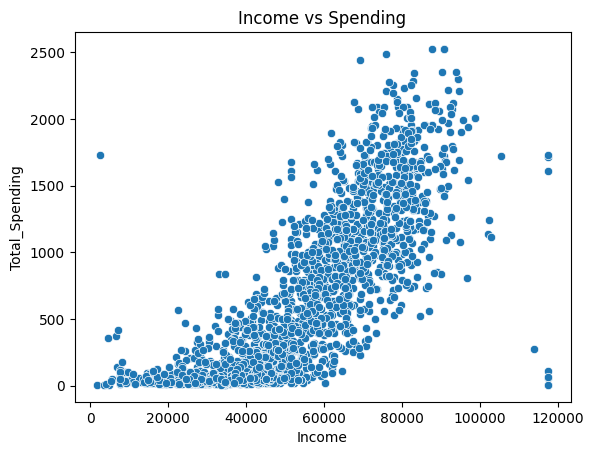

In [ ]:
sns.scatterplot(x='Income', y='Total_Spending', data=df)
plt.title('Income vs Spending')
plt.show()

Berdasarkan grafik scatter diatas Income vs Total Spending:
1. Terlihat korelasi positif yang kuat
2. semakin tinggi income, semakin besar total spending.
3. Pola titik membentuk tren naik yang jelas (bukan acak), menandakan hubungan yang konsisten.
4. Pelanggan dengan income menengah–tinggi (±50.000–90.000) memiliki spending paling besar.
5. Ada beberapa outlier (income tinggi tapi spending rendah, dan sebaliknya).
6. Income dapat menjadi prediktor kuat untuk memodelkan perilaku belanja pelanggan.


In [ ]:
from scipy.stats import pearsonr

corr, p = pearsonr(df['Income'], df['Total_Spending'])
print("Correlation:", corr)
print("p-value:", p)

alpha = 0.05

if p < alpha:
    print("Tolak H0: Terdapat korelasi yang signifikan antara Income dan Total_Spending")
else:
    print("Gagal menolak H0: Tidak terdapat korelasi yang signifikan antara Income dan Total_Spending")

Correlation: 0.8040831688302774
p-value: 0.0
Tolak H0: Terdapat korelasi yang signifikan antara Income dan Total_Spending


Berdasarkan uji Pearson, diperoleh p-value < 0.05 sehingga H0 ditolak. Hal ini menunjukkan bahwa terdapat korelasi positif yang signifikan antara income dan total spending pelanggan.

Artinya:
* Semakin tinggi income pelanggan, semakin besar total pengeluarannya.

* Income adalah fitur/prediktor yang sangat kuat untuk menjelaskan perilaku spending.

cat: "Uji Pearson digunakan karena kedua variabel bersifat numerik dan bertujuan untuk melihat hubungan linear."



###Segmentasi Customer

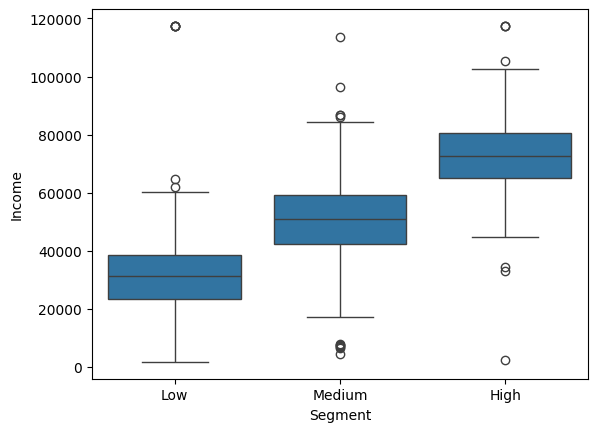

In [ ]:
df['Segment'] = pd.qcut(df['Total_Spending'], q=3, labels=['Low','Medium','High'])

sns.boxplot(x='Segment', y='Income', data=df)
plt.show()

Kesimpulan dari boxplot Segment vs Income:
1. Segment Low spending memiliki income paling rendah.
2. Segment Medium spending memiliki income menengah.
3. Segment High spending memiliki income paling tinggi.

Artinya:
* Segmentasi berdasarkan Total_Spending selaras dengan Income.
* Semakin tinggi income pelanggan, semakin tinggi segmen spending-nya.
* Income terbukti membedakan segmen pelanggan dengan jelas.

Income adalah faktor kunci yang membedakan pelanggan Low, Medium, dan High spender.

In [ ]:
from scipy.stats import f_oneway

low = df[df['Segment']=='Low']['Income']
med = df[df['Segment']=='Medium']['Income']
high = df[df['Segment']=='High']['Income']

stat, p = f_oneway(low, med, high)
print("p-value:", p)

alpha = 0.05

if p < alpha:
    print("Tolak H0: Ada perbedaan rata-rata Income antar segment")
else:
    print("Gagal menolak H0: Tidak ada perbedaan rata-rata Income antar segment")

p-value: 0.0
Tolak H0: Ada perbedaan rata-rata Income antar segment


Berdasarkan uji ANOVA, diperoleh p-value < 0.05 sehingga H0 ditolak. Hal ini menunjukkan bahwa terdapat perbedaan rata-rata income yang signifikan antara pelanggan pada segment Low, Medium, dan High.

cat: "ANOVA digunakan karena membandingkan rata-rata lebih dari dua kelompok.

###Campaign Effectiveness

In [ ]:
df['Response'].value_counts(normalize=True)

,proportion
Response,
0,0.850893
1,0.149107


cat: jika respons 1 pelanggan menerima penawaran, 0 jika tidak

1. 85% pelanggan tidak merespon campaign
2. Hanya 15% pelanggan yang menerima penawaran

artinya Menunjukkan efektivitas campaign masih rendah

In [ ]:
from scipy.stats import chi2_contingency

cont = pd.crosstab(df['Segment'], df['Response'])
chi2, p, dof, exp = chi2_contingency(cont)
print("p-value:", p)

alpha = 0.05
if p < alpha:
    print("Tolak H0: Ada hubungan antara segment dan response")
else:
    print("Gagal tolak H0: Tidak ada hubungan")

p-value: 2.2411192840373704e-21
Tolak H0: Ada hubungan antara segment dan response


Hasil:
p-value = 2.24e-21 (< 0.05)

Kesimpulan:
* Tolak H0 terdapat hubungan signifikan antara segment dan response
* Efektivitas campaign berbeda antar segment pelanggan


cat: 'Chi-Square digunakan karena variabel bersifat kategorikal.'


#DIAGNOSTIC ANALYSIS

Pada tahap ini, analisis tidak hanya berhenti pada “apa yang terjadi”, tetapi berfokus pada **mengapa hal tersebut terjadi**.

Berdasarkan hasil Exploratory Data Analysis sebelumnya, ditemukan beberapa pola utama:
- Sebagian pelanggan memberikan kontribusi revenue yang sangat besar
- Income berhubungan dengan spending
- Campaign marketing belum efektif

Oleh karena itu, dilakukan analisis lebih dalam untuk mencari akar penyebab dari fenomena tersebut.


### Apakah Revenue Didominasi oleh Sedikit Pelanggan?

In [ ]:
top_customers = df.sort_values(by='Total_Spending', ascending=False)

top_20 = top_customers.head(int(len(df)*0.2))
contribution = top_20['Total_Spending'].sum() / df['Total_Spending'].sum()

print("Kontribusi Top 20% Customer:", contribution)

Kontribusi Top 20% Customer: 0.523255916780399


**Insight:**
Jika kontribusi mendekati atau lebih dari 80%, maka terjadi fenomena Pareto (80/20), di mana sebagian kecil pelanggan menyumbang sebagian besar revenue.

Hal ini menunjukkan bahwa revenue perusahaan sangat bergantung pada pelanggan high-value.

**Makna Bisnis:**
Perusahaan perlu memprioritaskan retensi pelanggan high-value karena kehilangan mereka dapat berdampak besar terhadap revenue.

Ini menjadi dasar **strategic decision** untuk membuat program loyalty khusus.

###Kenapa Customer High-Value Bisa Tinggi Spending?

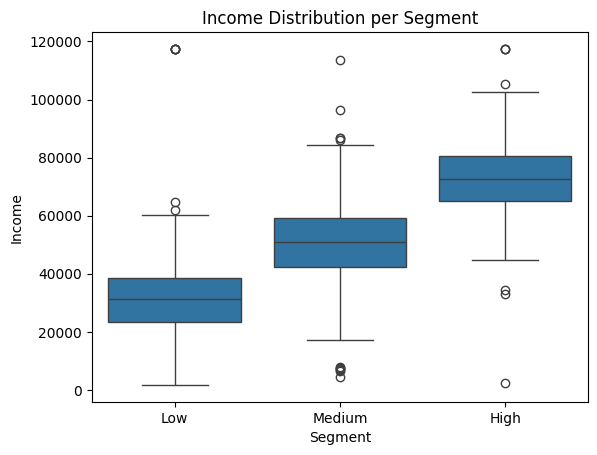

In [ ]:
sns.boxplot(x='Segment', y='Income', data=df)
plt.title('Income Distribution per Segment')
plt.show()

**Insight:**
Segment High memiliki distribusi income yang lebih tinggi dibandingkan segment lainnya.

Hal ini menunjukkan bahwa kemampuan finansial menjadi faktor utama dalam menentukan tingkat spending pelanggan.


Customer dengan income tinggi memiliki potensi lebih besar untuk berbelanja, sehingga campaign premium dapat diarahkan ke segmen ini sebagai bagian dari strategi **data-driven marketing**.

###Kenapa Campaign Marketing Tidak Efektif?

/tmp/ipykernel_22877/1297468183.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  response_rate = df.groupby('Segment')['Response'].mean()


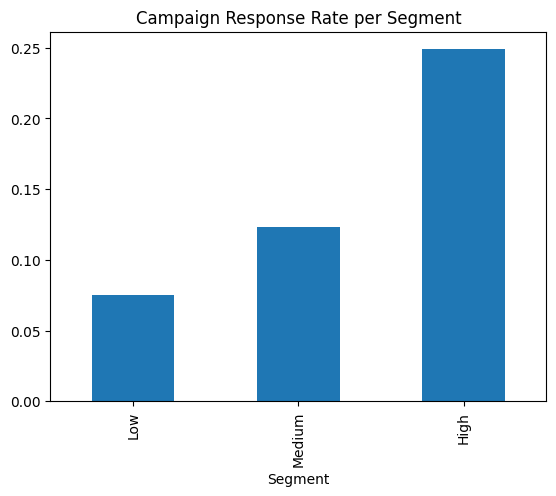

In [ ]:
response_rate = df.groupby('Segment')['Response'].mean()
response_rate.plot(kind='bar')
plt.title('Campaign Response Rate per Segment')
plt.show()

**Insight:**
Response rate cenderung rendah di semua segmen, atau hanya sedikit lebih tinggi di segmen tertentu.

Hal ini menunjukkan bahwa campaign belum cukup menarik atau belum tepat sasaran.


Campaign marketing kemungkinan besar masih bersifat general (tidak personalized), sehingga kurang relevan bagi pelanggan.

Perusahaan perlu mengarah ke pendekatan **personalized marketing** berbasis segmentasi.

##Channel Mana yang Paling Berpengaruh?

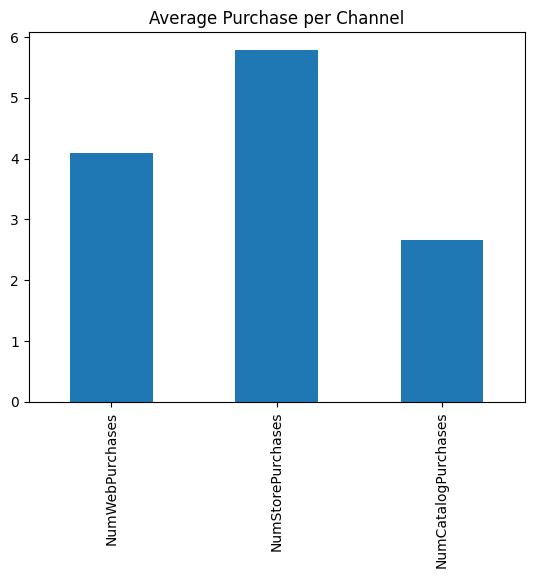

In [ ]:
channel = df[['NumWebPurchases','NumStorePurchases','NumCatalogPurchases']].mean()
channel.plot(kind='bar')
plt.title('Average Purchase per Channel')
plt.show()

**Insight:**
Terdapat channel yang lebih dominan digunakan pelanggan dibandingkan channel lainnya.

Ini menunjukkan preferensi perilaku belanja pelanggan.


Perusahaan dapat memfokuskan campaign pada channel yang paling sering digunakan untuk meningkatkan efektivitas dan efisiensi biaya marketing.

#CONCLUSION

1. Contribusi Revenue Tidak Merata
Top 20% customer berkontribusi sekitar 52% dari total revenue, menunjukkan bahwa perusahaan sangat bergantung pada high-value customers.
2. Income Memiliki Pengaruh Signifikan terhadap Spending
Customer dengan income tinggi cenderung memiliki total spending yang lebih besar, sehingga income menjadi faktor utama dalam menentukan nilai customer.
3. Produk Utama sebagai Revenue Driver
Kategori Wines dan Meat Products memberikan kontribusi terbesar terhadap total spending, sehingga menjadi driver utama revenue perusahaan.
4. Campaign Marketing Belum Efektif
Response rate hanya sekitar 14,91%, menunjukkan bahwa sebagian besar customer tidak merespons campaign yang diberikan.
5. Distribusi Customer Tidak Merata
Sebagian besar customer berada pada kategori low spender, sementara hanya sedikit customer yang termasuk high spender.



# Business Recommendation

##1. Maksimalkan High-Value Customers

Customer dengan kontribusi revenue tertinggi perlu diprioritaskan untuk meningkatkan profit.

* Buat program loyalty (member, point, reward)
* Kirim promo personal (diskon khusus, cashback)
* Gunakan channel direct marketing (email / WhatsApp) untuk engagement rutin


##2. Tingkatkan Efektivitas Campaign Marketing

Tidak semua campaign memberikan hasil optimal, sehingga perlu evaluasi dan perbaikan strategi.

* Hitung response rate tiap campaign
* Stop atau kurangi campaign yang tidak efektif
* Gunakan A/B testing untuk campaign baru
* Terapkan targeted campaign berdasarkan segment customer


##3. Terapkan Segmentasi Customer

Perbedaan perilaku customer menunjukkan perlunya strategi yang berbeda untuk tiap segmen.

* Segmentasikan customer: high, medium, low spender
* High → fokus retention (loyalty, VIP program)
* Medium → dorong upselling (bundling, rekomendasi produk)
* Low → aktivasi dengan promo (diskon, campaign awareness)


##4. Optimalkan Produk Terlaris

Produk dengan penjualan tertinggi dapat dimanfaatkan untuk meningkatkan revenue lebih lanjut.

* Pastikan stok produk terlaris selalu tersedia
* Jadikan produk terlaris sebagai highlight promosi
* Gunakan untuk bundling dengan produk lain
* Tempatkan produk terlaris di posisi strategis (toko / website)


##5. Tingkatkan Total Spending Customer

Masih terdapat peluang untuk meningkatkan nilai transaksi per customer.

* Terapkan cross-selling & up-selling
* Berikan rekomendasi produk berdasarkan histori pembelian
* Buat promo seperti “beli lebih banyak lebih hemat”
* Gunakan campaign khusus untuk meningkatkan average spending



